# SVM Sentiment Classifier — Stock Social Media Posts

Predicts sentiment class (`-1` = Bearish, `0` = Neutral, `1` = Bullish) from post text using TF-IDF + LinearSVC.

**Metrics reported per stock**: Accuracy, Confusion Matrix, Precision, Recall, F1 Score, MCC


In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    matthews_corrcoef,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
# ── Configuration ─────────────────────────────────────────────
DATA_DIR = os.path.join("..", "pre-processing")   # path to _final.csv files
STOCKS = ["aapl", "amzn", "fb", "nvda", "tsla"]
SAMPLE_SIZE = 50000         # rows per stock (stratified)
RANDOM_STATE = 42
TEST_SIZE = 0.20
MAX_TFIDF_FEATURES = 10_000
LABEL_MAP = {-1: "Bearish", 0: "Neutral", 1: "Bullish"}
LABEL_ORDER = [-1, 0, 1]
LABEL_NAMES = ["Bearish", "Neutral", "Bullish"]

## 1 — Load Data & Stratified Sampling

Each stock dataset is sampled to 50K rows (stratified by class) to keep SVM training fast while preserving class proportions.


In [3]:
# Load each _final.csv → clean (use all rows, no stratified sampling)
data = {}

for stock in STOCKS:
    path = os.path.join(DATA_DIR, f"{stock}_final.csv")
    print(f"Loading {stock} from {path} ...")
    df = pd.read_csv(path, low_memory=False)
    print(f"  Rows loaded: {len(df):,}")
    print(f"  Class distribution:\n{df['entities'].value_counts().sort_index().to_string()}")
    print()
    data[stock] = df

print("All datasets loaded.")

Loading aapl from ..\pre-processing\aapl_final.csv ...
  Rows loaded: 1,019,178
  Class distribution:
entities
-1    300255
 0    407703
 1    311220

Loading amzn from ..\pre-processing\amzn_final.csv ...
  Rows loaded: 606,172
  Class distribution:
entities
-1    163883
 0    268728
 1    173561

Loading fb from ..\pre-processing\fb_final.csv ...
  Rows loaded: 378,855
  Class distribution:
entities
-1    102265
 0    172039
 1    104551

Loading nvda from ..\pre-processing\nvda_final.csv ...
  Rows loaded: 645,161
  Class distribution:
entities
-1    169027
 0    302226
 1    173908

Loading tsla from ..\pre-processing\tsla_final.csv ...
  Rows loaded: 1,823,771
  Class distribution:
entities
-1    485585
 0    851139
 1    487047

All datasets loaded.


## 2 — TF-IDF Vectorization + Train/Test Split

We convert `body_clean` into TF-IDF features (unigrams + bigrams, top 10K features) and split 80/20 for each stock.


In [5]:
# Vectorize and split each stock
splits = {}  # stock → (X_train, X_test, y_train, y_test, vectorizer)

for stock in STOCKS:
    df = data[stock]
    print(f"Vectorizing {stock} ...")

    # Fill NaN in body_clean with empty string to avoid TfidfVectorizer error
    df["body_clean"] = df["body_clean"].fillna("")

    vectorizer = TfidfVectorizer(
        max_features=MAX_TFIDF_FEATURES,
        ngram_range=(1, 2),
        sublinear_tf=True,        # dampens term-frequency with 1 + log(tf)
    )

    X = vectorizer.fit_transform(df["body_clean"])
    y = df["entities"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )

    splits[stock] = (X_train, X_test, y_train, y_test, vectorizer)
    print(f"  Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}  |  Features: {X_train.shape[1]:,}")

print("\nVectorization complete.")

Vectorizing aapl ...
  Train: 815,342  |  Test: 203,836  |  Features: 10,000
Vectorizing amzn ...
  Train: 484,937  |  Test: 121,235  |  Features: 10,000
Vectorizing fb ...
  Train: 303,084  |  Test: 75,771  |  Features: 10,000
Vectorizing nvda ...
  Train: 516,128  |  Test: 129,033  |  Features: 10,000
Vectorizing tsla ...
  Train: 1,459,016  |  Test: 364,755  |  Features: 10,000

Vectorization complete.


---

# Training

Drop all Neutral (0) rows and classify only Bullish (1) vs Bearish (-1). This removes the noisy majority class where many posts simply had no sentiment detected.


aapl: 611,475 rows (Bearish=300,255, Bullish=311,220)
  Accuracy: 0.8738  |  F1(wtd): 0.8734  |  MCC: 0.7514
              precision    recall  f1-score   support

     Bearish       0.92      0.82      0.86     60051
     Bullish       0.84      0.93      0.88     62244

    accuracy                           0.87    122295
   macro avg       0.88      0.87      0.87    122295
weighted avg       0.88      0.87      0.87    122295


amzn: 337,444 rows (Bearish=163,883, Bullish=173,561)
  Accuracy: 0.8726  |  F1(wtd): 0.8723  |  MCC: 0.7460
              precision    recall  f1-score   support

     Bearish       0.90      0.84      0.86     32777
     Bullish       0.85      0.91      0.88     34712

    accuracy                           0.87     67489
   macro avg       0.87      0.87      0.87     67489
weighted avg       0.87      0.87      0.87     67489


fb: 206,816 rows (Bearish=102,265, Bullish=104,551)
  Accuracy: 0.8925  |  F1(wtd): 0.8922  |  MCC: 0.7879
              preci

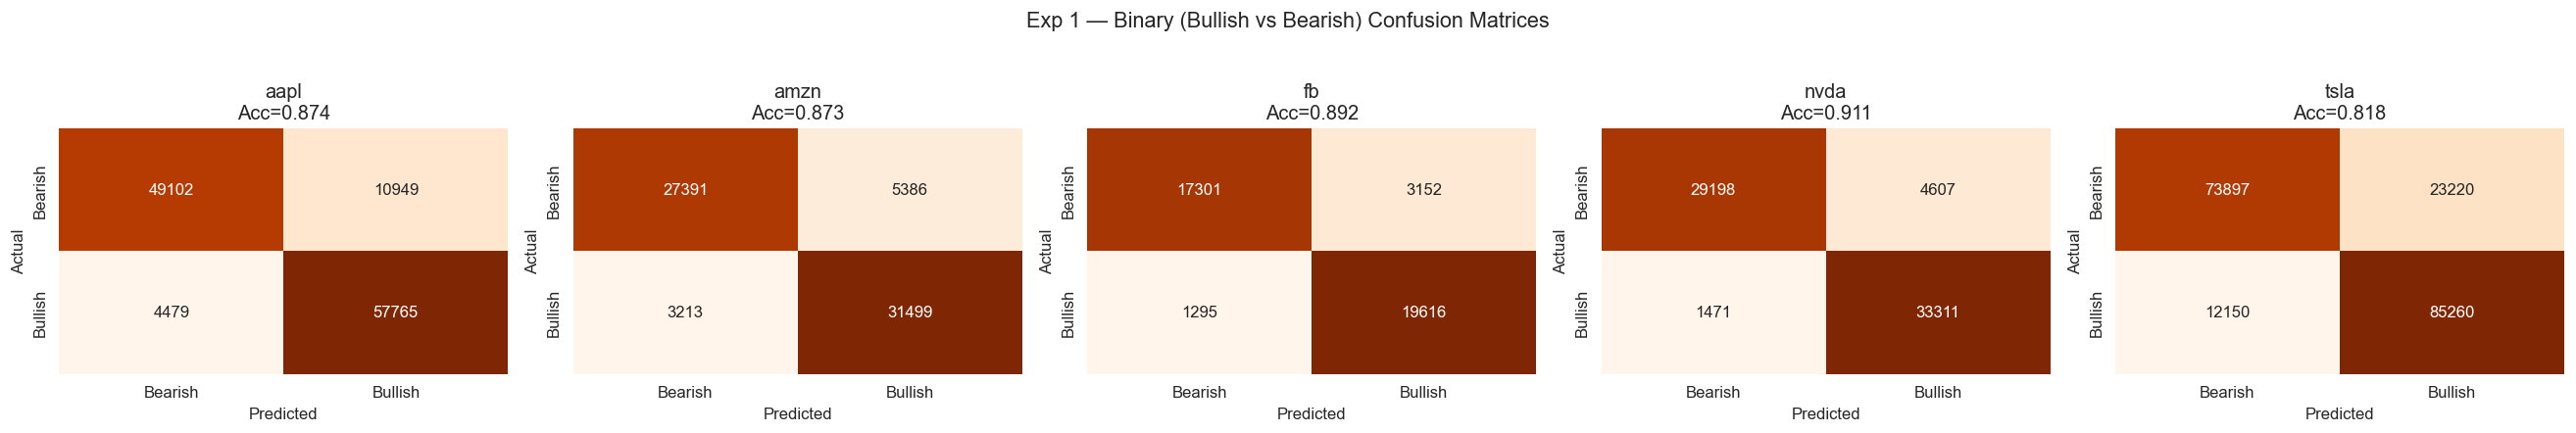

  3-Class vs Binary Comparison


,Binary Acc,Binary F1,Binary MCC
Stock,,,
aapl,0.873846,0.873371,0.751368
amzn,0.872587,0.872336,0.746048
fb,0.892491,0.892220,0.787931
nvda,0.911383,0.911139,0.825969
tsla,0.818174,0.817568,0.640449


In [7]:
# ── Experiment 1: Binary Classification (Bullish vs Bearish) ──────────
BINARY_LABELS = {-1: "Bearish", 1: "Bullish"}
BINARY_ORDER = [-1, 1]
BINARY_NAMES = ["Bearish", "Bullish"]

binary_results = {}

for stock in STOCKS:
    # Filter to only Bearish and Bullish
    df_bin = data[stock][data[stock]["entities"].isin([-1, 1])].copy()
    print(
        f"{stock}: {len(df_bin):,} rows (Bearish={sum(df_bin['entities']==-1):,}, Bullish={sum(df_bin['entities']==1):,})"
    )

    # TF-IDF
    vec_bin = TfidfVectorizer(
        max_features=MAX_TFIDF_FEATURES, ngram_range=(1, 2), sublinear_tf=True
    )
    X_bin = vec_bin.fit_transform(df_bin["body_clean"])
    y_bin = df_bin["entities"].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_bin, y_bin, test_size=TEST_SIZE, stratify=y_bin, random_state=RANDOM_STATE
    )

    # Train
    clf_bin = LinearSVC(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        dual=False,
    )
    clf_bin.fit(X_tr, y_tr)
    y_pr = clf_bin.predict(X_te)

    # Metrics
    acc = accuracy_score(y_te, y_pr)
    mcc = matthews_corrcoef(y_te, y_pr)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_te, y_pr, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_te, y_pr, labels=BINARY_ORDER)

    binary_results[stock] = {
        "accuracy": acc,
        "f1_weighted": f1_w,
        "mcc": mcc,
        "cm": cm,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "y_test": y_te,
        "y_pred": y_pr,
    }

    print(f"  Accuracy: {acc:.4f}  |  F1(wtd): {f1_w:.4f}  |  MCC: {mcc:.4f}")
    print(
        classification_report(
            y_te,
            y_pr,
            labels=BINARY_ORDER,
            target_names=BINARY_NAMES,
            zero_division=0,
        )
    )
    print()

# ── Confusion matrices ──
fig, axes = plt.subplots(1, 5, figsize=(22, 3.5))
fig.suptitle("Exp 1 — Binary (Bullish vs Bearish) Confusion Matrices", fontsize=13, y=1.04)
for ax, stock in zip(axes, STOCKS):
    cm = binary_results[stock]["cm"]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        xticklabels=BINARY_NAMES,
        yticklabels=BINARY_NAMES,
        ax=ax,
        cbar=False,
    )
    ax.set_title(f"{stock}\nAcc={binary_results[stock]['accuracy']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("exp1_binary_cm.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Comparison table ──
comp_rows = []
for stock in STOCKS:
    comp_rows.append(
        {
            "Stock": stock,
            "Binary Acc": binary_results[stock]["accuracy"],
            "Binary F1": binary_results[stock]["f1_weighted"],
            "Binary MCC": binary_results[stock]["mcc"],
        }
    )
comp_df = pd.DataFrame(comp_rows).set_index("Stock")
print("=" * 70)
print("  3-Class vs Binary Comparison")
print("=" * 70)
comp_df